## Comparing MMCIF2Dict vs. Bio.PDB.MMCIFParser for parsing speed

**Background**  
One of the core data ingestion steps is to parse structural data from `.cif` files to obtain $\text{C}\alpha$ coordinates and topologic information. There are 2 main architectural approaches we would like to compare:

1. **MMCIF2Dict** 
   - Direct, raw token-level access
   - Lightweight & fast execution
   - Lacks structural hierarchy / spatial topology
2. **Bio.PDB.MMCIFParser**
   - Standard object-oriented hierarchy (`Structure` $\rightarrow$ `Model` $\rightarrow$ `Chain` $\rightarrow$ `Residue` $\rightarrow$ `Atom`)
   - High abstraction level, easy to query
   - High memory overhead and slower execution

**Goal**  
In this notebook, we evaluate the baseline performance of `MMCIF2Dict` against `Bio.PDB.MMCIFParser` to quantify execution speed and peak memory efficiency.

**Hypothesis**  
Because `MMCIFParser` constructs a complete object tree, whereas `MMCIF2Dict` flattens tokens into native Python dictionaries, `MMCIF2Dict` will exhibit significantly lower latency and reduced memory footprint.

**Experiment**  
Using `8r3y.cif`, we execute both parsers over 50 paired iterations ($N = 50$) and measure wall-clock execution time and peak memory allocation (`tracemalloc`).

---

### Results Summary

#### 1. Execution Time (milliseconds)
| Parser | Mean | Std | Median | IQR | Min | Max |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **MMCIFParser** | 3791.04 | 485.39 | 3645.89 | 673.84 | 3129.14 | 5290.57 |
| **MMCIF2Dict** | 2197.15 | 226.15 | 2094.00 | 247.73 | 1999.70 | 2814.65 |

- **Execution Speed:** `MMCIF2Dict` is **1.74x faster** (based on median runtime).
- **Statistical Significance:** Wilcoxon Signed-Rank Test $p = 1.78 \times 10^{-15}$, Cohen's $d = 2.73$.

#### 2. Peak RAM Allocation (megabytes)
| Parser | Mean | Std | Median | IQR | Min | Max |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **MMCIFParser** | 37.83 | 0.00 | 37.83 | 0.00 | 37.83 | 37.84 |
| **MMCIF2Dict** | 17.18 | 0.00 | 17.18 | 0.00 | 17.18 | 17.19 |

- **Memory Footprint:** `MMCIF2Dict` reduces peak RAM consumption by **54.6%** (median).
- **Statistical Significance:** Wilcoxon Signed-Rank Test $p = 7.20 \times 10^{-10}$, Cohen's $d = 3.27 \times 10^4$.


### Conclusions
Based on these trade-offs, `MMCIF2Dict` was selected for the `StructureParser` class implementation.

In [1]:
import gc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tracemalloc
import time

from collections.abc import Callable
from pathlib import Path
from scipy import stats
from statannotations.Annotator import Annotator
from typing import Any

from Bio.PDB import MMCIF2Dict, MMCIFParser, PDBList


In [2]:
data_dir = Path("../data")
data_dir.mkdir(parents=True, exist_ok=True)

input_dir = data_dir / "input"
input_dir.mkdir(parents=True, exist_ok=True)

In [3]:
TEST_CIF_Paht = input_dir/ "8r3y.cif"

In [4]:
if TEST_CIF_Paht.is_file():
    print("8r3y.cif already exists")
    pass
else:
    pdbl = PDBList()

    raw_string_path = pdbl.retrieve_pdb_file(
        "8r3y", pdir=input_dir, file_format="mmCif"
    )

8r3y.cif already exists


In [5]:
def profile_parser_robust(
    parse_func: Callable[[Path], Any], file_path: str | Path, runs: int = 10
) -> tuple[list[float], list[float]]:
    """
    Profiles a parsing function over multiple iterations after a warm-up run.

    Measures total wall-clock time and peak memory consumption using `tracemalloc`.
    Includes an initial warm-up execution to prime module allocations and disk
    caches, followed by explicit garbage collection before each trial.

    Args:
        parse_func: Callable parsing function that accepts a single argument
          representing the file path to parse.
        file_path: Path to the structural coordinate file (`.cif`).
        runs: Number of benchmark iterations to execute after warm-up. Defaults
          to 10.

    Returns:
        tuple[list[float], list[float]]: A 2-element tuple containing:
            - times_ms: Measured execution times in milliseconds for each run.
            - peak_mbs: Measured peak RAM allocation in megabytes for each run.

    Raises:
        ValueError: If `runs` is less than 1.
    """
    if runs < 1:
        raise ValueError("The number of benchmark runs must be at least 1.")
    
    times_ms = []
    peak_mbs = []

    # Warm-up run (populates OS disk cache & handles initial module allocations)
    parse_func(file_path)

    for _ in range(runs):
        gc.collect()  # Clean heap before each run

        tracemalloc.start()
        start_time = time.perf_counter()

        _ = parse_func(file_path)

        end_time = time.perf_counter()
        _, peak_mem = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        times_ms.append((end_time - start_time) * 1000)
        peak_mbs.append(peak_mem / (1024 * 1024))

    return times_ms, peak_mbs


In [6]:
path = Path(TEST_CIF_Paht)
runs = 50

# MMCIFParser (Tree)
times_ms_tree, peak_mbs_tree = profile_parser_robust(
    lambda p: MMCIFParser(QUIET=True).get_structure("8R3Y", p),
    str(path),
    runs=runs,
)

# MMCIF2Dict (Dict)
times_ms_dict, peak_mbs_dict = profile_parser_robust(
    lambda p: MMCIF2Dict.MMCIF2Dict(p), str(path), runs=runs
)

df_measured_time_and_memory = pd.DataFrame(
    {
        "MMCIFParser_time": times_ms_tree,
        "MMCIFParser_memory": peak_mbs_tree,
        "MMCIF2Dict_time": times_ms_dict,
        "MMCIF2Dict_memory": peak_mbs_dict
    }
)

In [7]:
## Descriptive summary table
df_summary = pd.DataFrame(
    {
        "Mean": df_measured_time_and_memory.mean(),
        "Std": df_measured_time_and_memory.std(),
        "Median": df_measured_time_and_memory.median(),
        "IQR": df_measured_time_and_memory.quantile(0.75)
        - df_measured_time_and_memory.quantile(0.25),
        "Min": df_measured_time_and_memory.min(),
        "Max": df_measured_time_and_memory.max(),
    }
)
print("=== DESCRIPTIVE STATISTICS (N = 50) ===")
display(df_summary.round(2))

=== DESCRIPTIVE STATISTICS (N = 50) ===


,Mean,Std,Median,IQR,Min,Max
MMCIFParser_time,4136.01,457.89,3915.80,389.34,3643.68,5343.44
MMCIFParser_memory,37.67,0.00,37.67,0.00,37.67,37.67
MMCIF2Dict_time,2851.54,469.60,2719.05,766.03,2230.50,4246.36
MMCIF2Dict_memory,17.18,0.00,17.18,0.00,17.18,17.19


In [8]:
## Comparative Impact Metrics (Fold-Change & Reduction)
median_time_speedup = (
    df_summary.loc["MMCIFParser_time", "Median"]
    / df_summary.loc["MMCIF2Dict_time", "Median"]
)
median_mem_reduction = (
    1
    - (
        df_summary.loc["MMCIF2Dict_memory", "Median"]
        / df_summary.loc["MMCIFParser_memory", "Median"]
    )
) * 100

print("\n=== PERFORMANCE GAINS ===")
print(
    f"• Execution Time : MMCIF2Dict is {median_time_speedup:.2f}x faster (median)")
print(
    f"• Memory Footprint: MMCIF2Dict reduces peak RAM by {median_mem_reduction:.1f}% (median)")


=== PERFORMANCE GAINS ===
• Execution Time : MMCIF2Dict is 1.44x faster (median)
• Memory Footprint: MMCIF2Dict reduces peak RAM by 54.4% (median)


In [9]:
## We will use Wilcoxon Signed-Rank Test because the data points are paired for the following reasons:
## 1. Background processes (OS updates, background indexing, CPU frequency scaling) drift over time. 
## Run #1 of Parser A and Run #1 of Parser B occur under much closer system states than Run #1 and Run #50.
## 2. Both benchmarks are executed on the exact same hardware, operating system, and Python process 
## setup using the exact same input file

## Time comparison
w_time_stat, w_time_p = stats.wilcoxon(
    df_measured_time_and_memory["MMCIFParser_time"],
    df_measured_time_and_memory["MMCIF2Dict_time"],
)
## Cohen's d for Time
diff_time = (
    df_measured_time_and_memory["MMCIFParser_time"]
    - df_measured_time_and_memory["MMCIF2Dict_time"]
)
cohen_d_time = np.mean(diff_time) / np.std(diff_time, ddof=1)

## Memory comparison
w_mem_stat, w_mem_p = stats.wilcoxon(
    df_measured_time_and_memory["MMCIFParser_memory"],
    df_measured_time_and_memory["MMCIF2Dict_memory"],
)
## Cohen's d for Memory
diff_mem = (
    df_measured_time_and_memory["MMCIFParser_memory"]
    - df_measured_time_and_memory["MMCIF2Dict_memory"]
)
cohen_d_mem = np.mean(diff_mem) / np.std(diff_mem, ddof=1)

print("\n=== HYPOTHESIS TESTING (Wilcoxon Signed-Rank Test & Cohen's d) ===")
print(
    f"• Time   : W = {w_time_stat:.0f}, p = {w_time_p:.2e} | Cohen's d = {cohen_d_time:.3f}")
print(
    f"• Memory : W = {w_mem_stat:.0f}, p = {w_mem_p:.2e} | Cohen's d = {cohen_d_mem:.3f}")


=== HYPOTHESIS TESTING (Wilcoxon Signed-Rank Test & Cohen's d) ===
• Time   : W = 1, p = 3.55e-15 | Cohen's d = 1.921
• Memory : W = 0, p = 1.78e-15 | Cohen's d = 34906.047


/var/folders/vl/cjsy8yl950v05vbldt2pr2pr0000gn/T/ipykernel_76652/74719547.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/vl/cjsy8yl950v05vbldt2pr2pr0000gn/T/ipykernel_76652/74719547.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


MMCIFParser vs. MMCIF2Dict: Wilcoxon test (paired samples), P_val:3.553e-15 Stat=1.000e+00
MMCIFParser vs. MMCIF2Dict: Wilcoxon test (paired samples), P_val:1.776e-15 Stat=0.000e+00


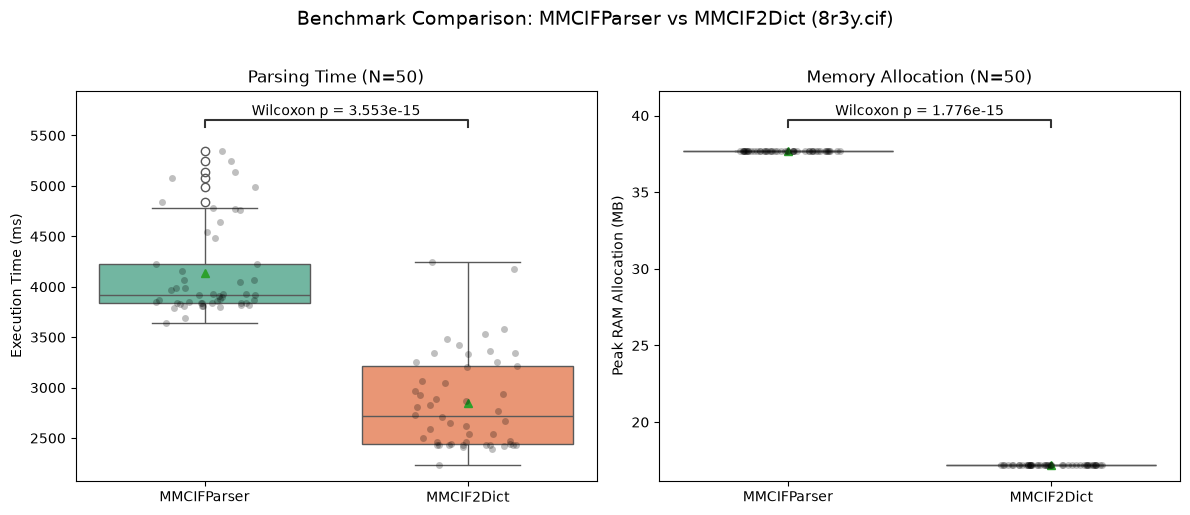

In [10]:
## Reshape data into long format for clean Seaborn + Statannotations integration
df_long = pd.melt(
    df_measured_time_and_memory,
    var_name="Metric_Parser",
    value_name="Value",
)

## Split the variable column into distinct Parser and Metric columns
df_long["Parser"] = df_long["Metric_Parser"].apply(
    lambda x: "MMCIFParser" if "MMCIFParser" in x else "MMCIF2Dict"
)
df_long["Metric"] = df_long["Metric_Parser"].apply(
    lambda x: "Execution Time (ms)" if "time" in x else "Peak RAM (MB)"
)

## Filter data for the two subplots
df_time = df_long[df_long["Metric"] == "Execution Time (ms)"]
df_mem = df_long[df_long["Metric"] == "Peak RAM (MB)"]

# Define the pairs to compare
pairs = [("MMCIFParser", "MMCIF2Dict")]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

## --- Subplot 1: Execution Time ---
sns.boxplot(
    data=df_time,
    x="Parser",
    y="Value",
    ax=ax1,
    palette="Set2",
    showmeans=True,
)
sns.stripplot(
    data=df_time,
    x="Parser",
    y="Value",
    ax=ax1,
    color="black",
    alpha=0.25,
    jitter=0.2,
)

annotator1 = Annotator(ax1, pairs, data=df_time, x="Parser", y="Value")
annotator1.configure(
    test="Wilcoxon", text_format="full", loc="inside", verbose=2
)
annotator1.apply_and_annotate()

ax1.set_ylabel("Execution Time (ms)")
ax1.set_xlabel("")
ax1.set_title("Parsing Time (N=50)")

## --- Subplot 2: Memory Footprint ---
sns.boxplot(
    data=df_mem,
    x="Parser",
    y="Value",
    ax=ax2,
    palette="Set2",
    showmeans=True,
)
sns.stripplot(
    data=df_mem,
    x="Parser",
    y="Value",
    ax=ax2,
    color="black",
    alpha=0.25,
    jitter=0.2,
)

annotator2 = Annotator(ax2, pairs, data=df_mem, x="Parser", y="Value")
annotator2.configure(
    test="Wilcoxon", text_format="full", loc="inside", verbose=2
)
annotator2.apply_and_annotate()

ax2.set_ylabel("Peak RAM Allocation (MB)")
ax2.set_xlabel("")
ax2.set_title("Memory Allocation (N=50)")

fig.suptitle(
    "Benchmark Comparison: MMCIFParser vs MMCIF2Dict (8r3y.cif)",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.show()